## $ \text{II} $ - Données relationnelles (Partie Pubmed et Citeseer )

### IMPORTATION DES BIBLIOTHÈQUES ET CLASSE QU'ON A NOUS MÊME DÉFINIES

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tranformation import Load
from preprocessing import Echantillonnage, Processing

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.naive_bayes import BernoulliNB
from sklearn.naive_bayes import MultinomialNB

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score

from keras import Sequential
from keras.layers import Dense, Dropout

from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier


In [ ]:
# Instanciation de nos classes métiers qu'on a crée dans le but de réduire la taille du notebook
#mais aussi rendre le code modulable
# des commentaires Doc sont disponibles pour chaque classe
load_data = Load()
sampling = Echantillonnage()
process = Processing()

### Récupération des jeux de données et EQUILIBRAGE

In [ ]:
# Récupération de nos données avec le process de la classe Load
fea_pubmed, gnd_pubmed, W_pubmed , D_pubmed, M_pubmed = load_data.load_data('pubmed.mat')
fea_cora, gnd_cora, W_cora, D_cora, M_cora = load_data.load_data('cora.mat')
fea_citeseer, gnd_citeseer, W_citeseer, D_citeseer, M_citeseer = load_data.load_data('citeseer.mat')

***********************************distribution de citeseer gnd*********************************


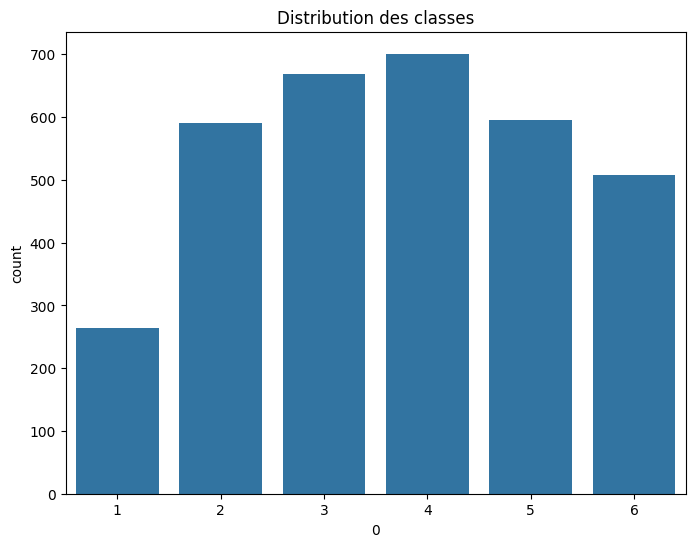



***********************************distribution de pubmed gnd*********************************


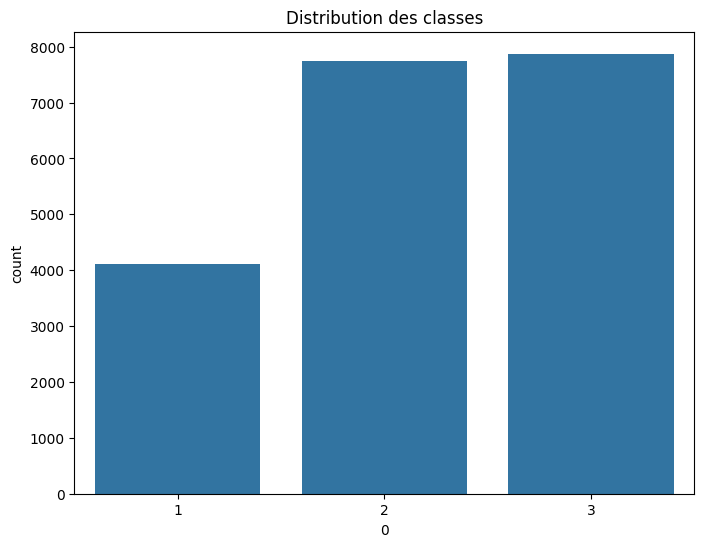



***********************************distribution de cora gnd*********************************


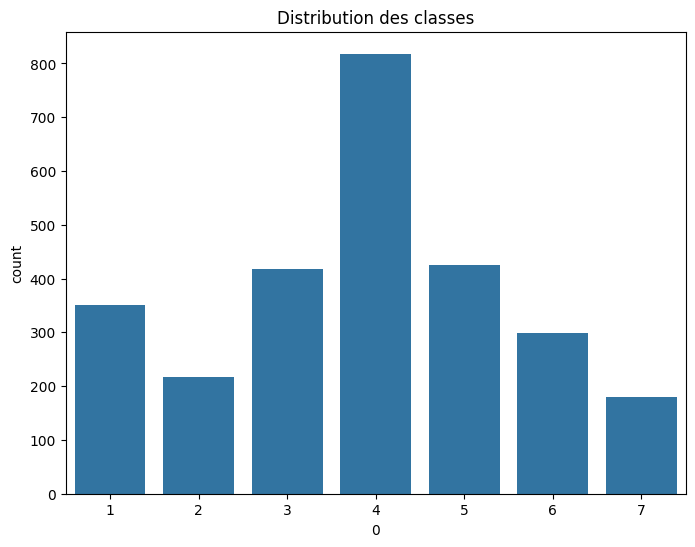

In [ ]:
# Distribution de nos classes des trois jeux de données
print('***********************************distribution de citeseer gnd*********************************')
sampling.plot_distribution(gnd_citeseer,'distribution de citeseer gnd')
print('\n')
print('***********************************distribution de pubmed gnd*********************************')
sampling.plot_distribution(data=gnd_pubmed,title='distribution de pubmed gnd')
print('\n')
print('***********************************distribution de cora gnd*********************************')
sampling.plot_distribution(data=gnd_cora,title='distribution de cora gnd')


Du fait de la nature des données des dataset cora et citesser, des méthodes comme la regression logistique, Gaussian naïve Bayes et SVM linéaire
exploitent bien les représentations binaires sans étapes supplémentaires.

Les Trois Méthodes choisies seront ces trois là dans l'un des deux jeux de données et d'autres méthodes seront explorer malgrès le type de données.

Car dans la littérature, ce qui est observé le plus souvent, est relayé et parfois s'accompagne de preuves mathématiques.
Toute fois des imprévus se présente assez souvent.

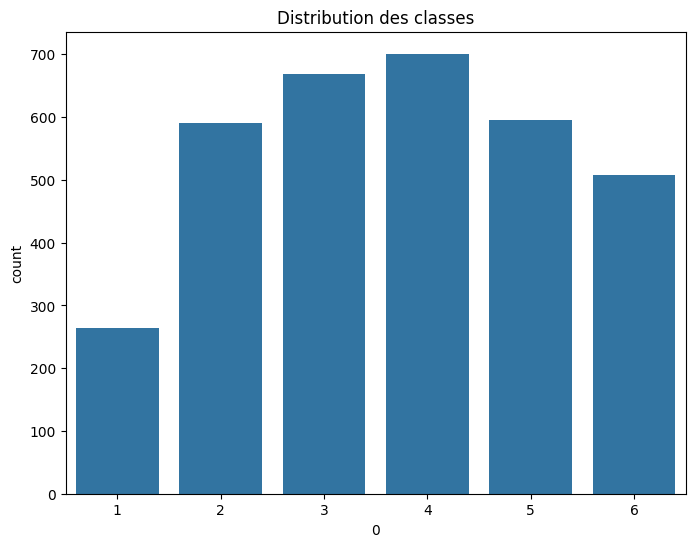

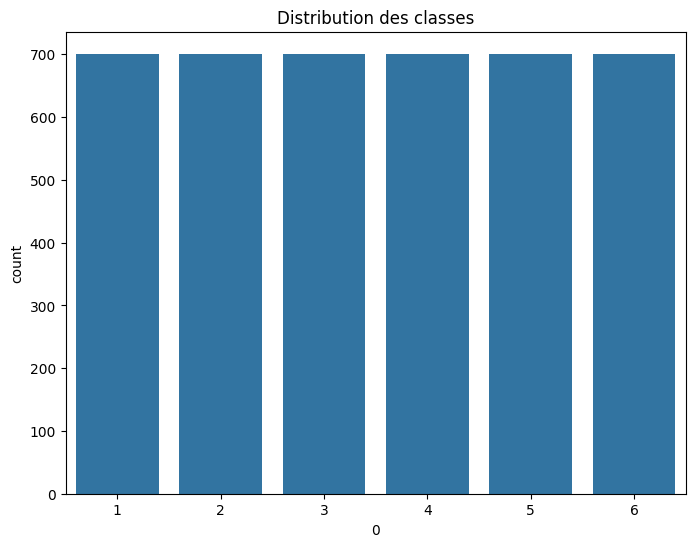

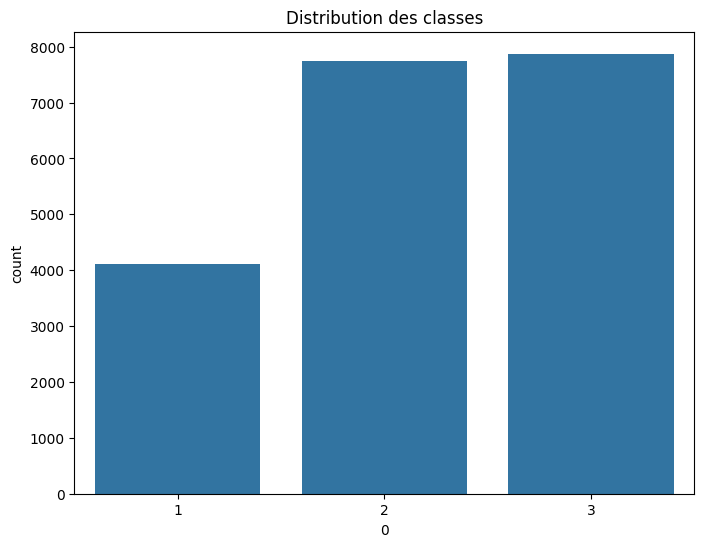

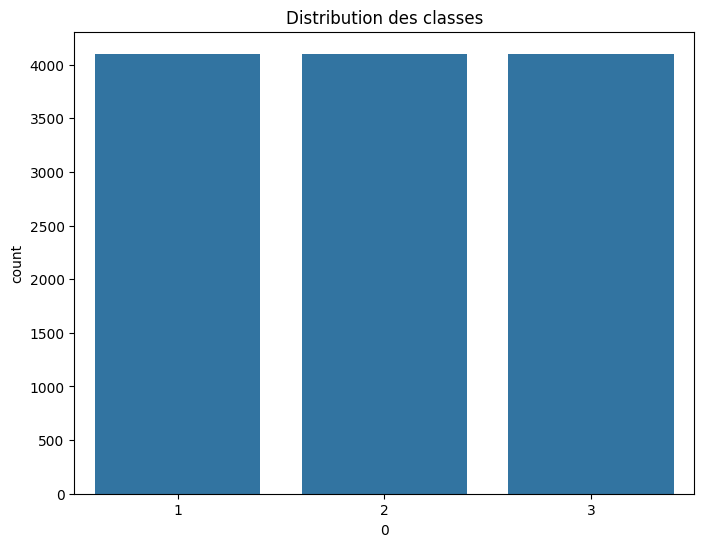

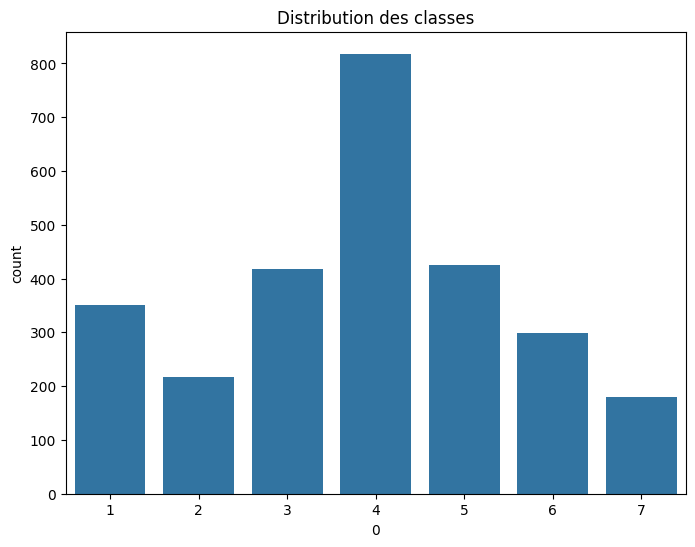

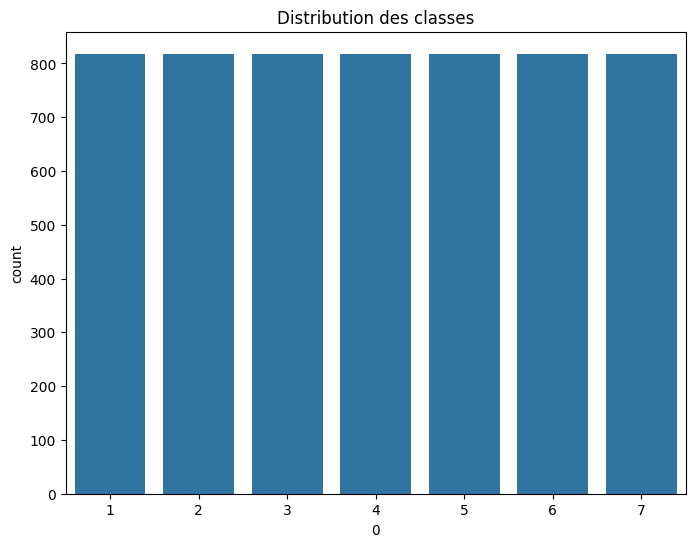

In [ ]:
# Equilibrage des classes


#citeseer SMOTE SAMPLING
fea_citeseer_sampling, gnd_citeseer_sampling = sampling.smote_sampling(fea_citeseer, gnd_citeseer)


#pubmed UNDERSAMPLING
fea_pubmed_sampling, gnd_pubmed_sampling = sampling.under_sampling(fea_pubmed, gnd_pubmed)


#cora OVERSAMPLING
fea_cora_sampling, gnd_cora_sampling = sampling.over_sampling(fea_cora, gnd_cora)

### CITISEER

In [ ]:
# Création des models avant les équilibrages

models = []

# Logistic Regression avec Elastic Net (multiclasse softmax)
lr = LogisticRegression(
    penalty='elasticnet', solver='saga', l1_ratio=0.5, max_iter=1000, C=1.0, multi_class='multinomial'
)
models.append(('Logistic Regression (Elastic Net)', lr))

# Naive Bayes (Bernoulli)
nb = BernoulliNB()
models.append(('Naive Bayes (Bernoulli)', nb))

# SVM linéaire pour multiclasse avec OvR (One-vs-Rest)
svm = SVC(kernel='linear', C=1.0, decision_function_shape='ovr')
models.append(('SVM (Linear OvR)', svm))

In [ ]:
cv_results = process.cross_val(models=models, num_folds=5, X_train=fea_citeseer, Y_train=gnd_citeseer)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/sit

Logistic Regression (Elastic Net): 0.710543 (0.019617)


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/uti

Naive Bayes (Bernoulli): 0.740590 (0.026191)


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/uti

SVM (Linear OvR): 0.694609 (0.021093)


In [ ]:
# Comparaison des models avant les équilibrages


Après entrainement sur notre jeux de données déséquilibrées, on voit que le meilleur model est celui de Naive Bayes (Bernoulli) avec un accuracy de 0,74.

On va faire de même avec le jeux de données équilibré pour voir ce que donneront les résultats avec ces trois méthodes choisies préalablement.

Puis on se penchera sur d'autre méthodes à la volet afin de regarder s'ils performeront malgré le type de données

In [ ]:
# Création des models après les équilibrages

#fea_citeseer_sampling, gnd_citeseer_sampling

X_train, X_test, y_train, y_test = process.train_test(fea_citeseer_sampling, gnd_citeseer_sampling)

cv_results_sampling = process.cross_val(models=models, num_folds=5, X_train=X_train, Y_train=y_train)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y wa

In [ ]:
# Comparaison des models après les équilibrages

Après avoir équilibré les classe avec Oversampling, nous avons observé que le model qui a marché les mieux est GVUECLHBI.

Nous allons à présent explorer un piste qui la recherhce des meilleurs paramétres avec notre meilleurs model.

On a voulu faire de même avec les autres méthodes mais le calcul prends du temps de ce fait la recherche
des meilleurs paramètres se limitera au meilleur obtenu après équilibrage

In [ ]:
# Recherche de meilleurs paramètres avec Grid Search CV

# rescaledX = X_train
rescaledX = process.scaler(X_train) # on aurait besoin de celui la si la méthode choisi n'était pas celle de bernouilli afin de centré et réduire

# Paramètres à tester pour BernoulliNB
param_grid = {'alpha': [0.1, 0.5, 1.0, 2.0], 'binarize': [0.0, 0.5, 1.0]}

# Création du modèle
best_model = BernoulliNB()

# KFold pour la validation croisée
kfold = KFold(n_splits=5, random_state=42, shuffle=True)

# Recherche par grille
grid = GridSearchCV(estimator=best_model, param_grid=param_grid, scoring='accuracy', cv=kfold)
grid_result = grid.fit(X_train, y_train)

# Affichage des résultats
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))
means = grid_result.cv_results_['mean_test_score']
stds = grid_result.cv_results_['std_test_score']
params = grid_result.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/uti

Best: 0.791623 using {'alpha': 0.1, 'binarize': 0.0}
0.791623 (0.011306) with: {'alpha': 0.1, 'binarize': 0.0}
0.791623 (0.011306) with: {'alpha': 0.1, 'binarize': 0.5}
0.291619 (0.008539) with: {'alpha': 0.1, 'binarize': 1.0}
0.787165 (0.015284) with: {'alpha': 0.5, 'binarize': 0.0}
0.787165 (0.015284) with: {'alpha': 0.5, 'binarize': 0.5}
0.293106 (0.010130) with: {'alpha': 0.5, 'binarize': 1.0}
0.781218 (0.011592) with: {'alpha': 1.0, 'binarize': 0.0}
0.781218 (0.011592) with: {'alpha': 1.0, 'binarize': 0.5}
0.294296 (0.008256) with: {'alpha': 1.0, 'binarize': 1.0}
0.769326 (0.011791) with: {'alpha': 2.0, 'binarize': 0.0}
0.769326 (0.011791) with: {'alpha': 2.0, 'binarize': 0.5}
0.295485 (0.008898) with: {'alpha': 2.0, 'binarize': 1.0}


In [ ]:
# Utilisation des autres méthodes même un model MLP de deep learning inclu

# models à comparer trois méthodes max pour chaque ensembles de données
models = []
models.append(('LDA', LinearDiscriminantAnalysis()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
models.append(('NB', GaussianNB()))
models.append(('SVM', SVC(kernel='rbf', C=1.0, gamma='scale')))


In [ ]:
cv_results = process.cross_val(models=models, num_folds=5, X_train=fea_citeseer, Y_train=gnd_citeseer)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/uti

LDA: 0.378106 (0.024687)


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neighb

KNN: 0.086868 (0.013036)
CART: 0.602640 (0.012418)


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/uti

NB: 0.615864 (0.023845)


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/uti

SVM: 0.733086 (0.017289)


In [ ]:
def model(X, y) :

    model = Sequential()
    model.add(Dense(units = 128, activation='relu', input_dim=X.shape[1]))
    model.add(Dropout(rate=0.2))
    model.add(Dense(units = 64, activation='relu'))
    model.add(Dropout(rate=0.2))
    model.add(Dense(units = y.nunique()[0], activation='softmax'))
    model.compile(optimizer='Adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    return model

In [ ]:
gnd_citeseer_ = gnd_citeseer - 1

model = model(fea_citeseer, gnd_citeseer_)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
history = model.fit(fea_citeseer, gnd_citeseer_, epochs=5, batch_size=48)

Epoch 1/5
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9662 - loss: 0.1533
Epoch 2/5
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9872 - loss: 0.0880
Epoch 3/5
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9934 - loss: 0.0502
Epoch 4/5
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9936 - loss: 0.0374
Epoch 5/5
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9937 - loss: 0.0293


In [ ]:
# Conclusion Générale

Au regard du résultat obtenu, on peut dire avec certitude que notre architecture MLP marche mieux sur ces données que les model de machine learning utilisé sur ce jeux de données.

l'accuracy obtenu sur ces données sont de l'ordre de 99% ce qui marque une réelle différence avec les autres méthodes qui l'accuracy la plus élevé enregistré est environ 75%.

Donc avec ce jeux de donnée notre architecture MLP à trois couche avec des couche de régularisation intermédiare performe mieux.

##### Conclusion Générale :

Ce jeux de données est du même type que le précedent et donc les même performances ont été observées.
Par contre Naïve baise Bernouilli performe mieux avec ce jeux de données avec un score de 85%, on a observé ce résultat avec GridSearchCv

Mais les performances de notre architecture MLP présente toujours les meilleurs résultats. avec un score de 99%

### PUBMED

Ce jeux de données est un peu différent des autres. En effet dans celui là, une vectorisation par tfidf a été faite.

Du coup on garde LogisticRegression et SVM par contre MultinomialNB sera utilisé à la place de BernoulliNB

In [ ]:
# Création des models avant les équilibrages

models = []

# Logistic Regression avec Elastic Net (multiclasse softmax)
lr = LogisticRegression(
    penalty='elasticnet', solver='saga', l1_ratio=0.5, max_iter=1000, C=1.0
)
models.append(('Logistic Regression (Elastic Net)', lr))

# Naive Bayes (Bernoulli)
nb = MultinomialNB()
models.append(('Naive Bayes (Multinomial)', nb))

# SVM linéaire pour multiclasse avec OvR (One-vs-Rest)
svm = SVC(kernel='linear', C=1.0, decision_function_shape='ovr')
models.append(('SVM (Linear OvR)', svm))

cv_results = process.cross_val(models=models, num_folds=5, X_train=fea_pubmed, Y_train=gnd_pubmed)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/sit

Logistic Regression (Elastic Net): 0.869453 (0.005069)
Naive Bayes (Bernoulli): 0.783080 (0.007135)


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/uti

SVM (Linear OvR): 0.867728 (0.003844)


In [ ]:
#fea_pubmed_sampling, gnd_pubmed_sampling

X_train, X_test, y_train, y_test = process.train_test(fea_pubmed_sampling, gnd_pubmed_sampling)

In [ ]:
cv_results_sampling = process.cross_val(models=models, num_folds=5, X_train=X_train, Y_train=y_train)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/sit

Logistic Regression (Elastic Net): 0.879894 (0.005958)


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/uti

Naive Bayes (Bernoulli): 0.807989 (0.008294)


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/uti

SVM (Linear OvR): 0.875926 (0.004841)


In [ ]:
# Recherche de meilleurs paramètres avec Grid Search CV


# Hyperparamètres à tester
param_grid_lr = {
    'C': [0.01, 0.1, 1.0, 10.0],  # Paramètre de régularisation
    'solver': ['lbfgs', 'liblinear'],  # Solveurs classiques
    'penalty': ['l2']  # 'l1' nécessite liblinear ou saga
}

# Modèle de base
lr_model = LogisticRegression(max_iter=1000)

# Validation croisée
kfold = KFold(n_splits=5, random_state=42, shuffle=True)

# Grid Search
grid_lr = GridSearchCV(estimator=lr_model, param_grid=param_grid_lr, scoring='accuracy', cv=kfold)
grid_result_lr = grid_lr.fit(fea_pubmed, gnd_pubmed)

# Affichage des résultats
print("Best Logistic Regression Score: %f using %s" % (grid_result_lr.best_score_, grid_result_lr.best_params_))
for mean, stdev, param in zip(grid_result_lr.cv_results_['mean_test_score'], grid_result_lr.cv_results_['std_test_score'], grid_result_lr.cv_results_['params']):
    print("%f (%f) with: %r" % (mean, stdev, param))


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/uti

Best Logistic Regression Score: 0.877618 using {'C': 10.0, 'penalty': 'l2', 'solver': 'lbfgs'}
0.652483 (0.007841) with: {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
0.648780 (0.008635) with: {'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}
0.819496 (0.004654) with: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
0.804838 (0.003506) with: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
0.864279 (0.004612) with: {'C': 1.0, 'penalty': 'l2', 'solver': 'lbfgs'}
0.859005 (0.004394) with: {'C': 1.0, 'penalty': 'l2', 'solver': 'liblinear'}
0.877618 (0.003051) with: {'C': 10.0, 'penalty': 'l2', 'solver': 'lbfgs'}
0.875691 (0.002950) with: {'C': 10.0, 'penalty': 'l2', 'solver': 'liblinear'}


In [ ]:
# Hyperparamètres à tester
param_grid_svm = {
    'C': [0.1, 1],  # Régularisation
    'kernel': ['linear', 'rbf'],  # Noyau linéaire ou RBF
    'gamma': ['scale', 'auto']  # Appliqué aux noyaux RBF
}

# Modèle de base
svm_model = SVC()

# Grid Search
grid_svm = GridSearchCV(estimator=svm_model, param_grid=param_grid_svm, scoring='accuracy', cv=kfold)
grid_result_svm = grid_svm.fit(fea_pubmed, gnd_pubmed)

# Affichage des résultats
print("Best SVM Score: %f using %s" % (grid_result_svm.best_score_, grid_result_svm.best_params_))
for mean, stdev, param in zip(grid_result_svm.cv_results_['mean_test_score'], grid_result_svm.cv_results_['std_test_score'], grid_result_svm.cv_results_['params']):
    print("%f (%f) with: %r" % (mean, stdev, param))

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/uti

On a chercher les meilleurs parametres pour SVM et Régression Logistique vu qu'ils s'équivalaient à première vu.

Par contre après avoir effectué une recherche par grille des meilleurs paramètres on s'est rendu compte que la SVM s'en sort un tout petit peu mieux que la Regression Logistique.

In [ ]:
# Utilisation des autres méthodes même un model MLP de deep learning inclu

models_ = []
models_.append(('LDA', LinearDiscriminantAnalysis()))
models_.append(('KNN', KNeighborsClassifier()))
models_.append(('CART', DecisionTreeClassifier()))
models_.append(('NB', GaussianNB()))
models_.append(('SVM', SVC(kernel='rbf', C=1.0, gamma='scale')))

cv_results = process.cross_val(models=models_, num_folds=5, X_train=fea_pubmed, Y_train=gnd_pubmed)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/uti

LDA: 0.869453 (0.003834)


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neighb

KNN: 0.770959 (0.004710)
CART: 0.824872 (0.004452)


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/uti

NB: 0.752243 (0.007864)


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/uti

SVM: 0.884415 (0.002537)


In [ ]:
fea_pubmed.shape

(19717, 500)

In [ ]:
gnd_pubmed_ = gnd_pubmed - 1

model = model(fea_pubmed, gnd_pubmed_)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
history = model.fit(fea_pubmed, gnd_pubmed_, epochs=5, batch_size=48)

Epoch 1/5
411/411 ━━━━━━━━━━━━━━━━━━━━ 0s 734us/step - accuracy: 0.9801 - loss: 0.0617
Epoch 2/5
411/411 ━━━━━━━━━━━━━━━━━━━━ 0s 624us/step - accuracy: 0.9846 - loss: 0.0508
Epoch 3/5
411/411 ━━━━━━━━━━━━━━━━━━━━ 0s 628us/step - accuracy: 0.9854 - loss: 0.0454
Epoch 4/5
411/411 ━━━━━━━━━━━━━━━━━━━━ 0s 598us/step - accuracy: 0.9862 - loss: 0.0454
Epoch 5/5
411/411 ━━━━━━━━━━━━━━━━━━━━ 0s 614us/step - accuracy: 0.9900 - loss: 0.0330


##### Conclusion

Bien que des méthodes se sont distingué telque la LDA, Regression logistique et SVM qui d'ailleur est le meilleur.

On a testé aussi notre architecture de réseau de neuronnes à trois couche qui se trouve encore meilleure.

Nous allons attaquer les matrice M dans la suite de ce travail.
Mais avant cela, nous allons effectuer un acp sur nos jeux de données avec nos meilleurs models de machine learning afin de les comparer à notre architecture MLP.

#### PCA + Methodes

In [ ]:
models = []
models.append(('LDA', LinearDiscriminantAnalysis()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
models.append(('NB', GaussianNB()))
models.append(('SVM', SVC(kernel='rbf', C=1.0, gamma='scale')))
models.append(('AB', AdaBoostClassifier()))
models.append(('GBM', GradientBoostingClassifier()))
models.append(('RF', RandomForestClassifier()))
models.append(('ET', ExtraTreesClassifier()))

In [ ]:
# Réduction de dimension à deux composantes pour chaque jeux de données

df_pca_citeseer, pca_chart_citeseer =  process.dimred_with_pca(fea_citeseer_sampling, gnd_citeseer_sampling)
df_pca_cora, pca_chart_cora =  process.dimred_with_pca(fea_cora_sampling, gnd_cora_sampling)
df_pca_pubmed, pca_chart_pubmed =  process.dimred_with_pca(fea_pubmed_sampling, gnd_pubmed_sampling)

In [ ]:
for name, model in models :

    # Réduction de dimension à deux composantes pour chaque jeux de données

    # df_pca_citeseer contient les colonnes 'x', 'y', et 'gnd' (étiquettes)
    X_pca = df_pca_citeseer[['x', 'y']]  # Composantes principales
    y = df_pca_citeseer['gnd']  # Étiquettes

    # Séparation en ensembles d'entraînement et de test
    X_train, X_test, y_train, y_test = process.train_test(X_pca, y)

    # Entraînement du modèle
    model.fit(X_train, y_train)

    # Prédictions
    y_pred = model.predict(X_test)

    # Évaluation du modèle
    accuracy = accuracy_score(y_test, y_pred)
    print(f'Accuracy of {name} with PCA: {accuracy:.2f}')

Accuracy of LDA with PCA: 0.26
Accuracy of KNN with PCA: 0.29
Accuracy of CART with PCA: 0.28
Accuracy of NB with PCA: 0.25
Accuracy of SVM with PCA: 0.25
Accuracy of AB with PCA: 0.33


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Accuracy of GBM with PCA: 0.33
Accuracy of RF with PCA: 0.29
Accuracy of ET with PCA: 0.28


In [ ]:
for name, model in models :

    # Réduction de dimension à deux composantes pour chaque jeux de données

    # df_pca_cora contient les colonnes 'x', 'y', et 'gnd' (étiquettes)
    X_pca = df_pca_cora.drop('gnd', axis=1) # Composantes principales
    y = df_pca_cora['gnd']  # Étiquettes

    # Séparation en ensembles d'entraînement et de test
    X_train, X_test, y_train, y_test = process.train_test(X_pca, y)

    # Entraînement du modèle
    model.fit(X_train, y_train)

    # Prédictions
    y_pred = model.predict(X_test)

    # Évaluation du modèle
    accuracy = accuracy_score(y_test, y_pred)
    print(f'Accuracy of {name} with PCA ( Cora): {accuracy:.2f}')

Accuracy of LDA with PCA: 0.24
Accuracy of KNN with PCA: 0.21
Accuracy of CART with PCA: 0.21
Accuracy of NB with PCA: 0.24
Accuracy of SVM with PCA: 0.24
Accuracy of AB with PCA: 0.20


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Accuracy of GBM with PCA: 0.25
Accuracy of RF with PCA: 0.24
Accuracy of ET with PCA: 0.21


In [ ]:
for name, model in models :

    # Réduction de dimension à deux composantes pour chaque jeux de données

    # df_pca_pubmed contient les colonnes 'x', 'y', et 'gnd' (étiquettes)
    X_pca = df_pca_pubmed[['x', 'y']]  # Composantes principales
    y = df_pca_pubmed['gnd']  # Étiquettes

    # Séparation en ensembles d'entraînement et de test
    X_train, X_test, y_train, y_test = process.train_test(X_pca, y)

    # Entraînement du modèle
    model.fit(X_train, y_train)

    # Prédictions
    y_pred = model.predict(X_test)

    # Évaluation du modèle
    accuracy = accuracy_score(y_test, y_pred)
    print(f'Accuracy of {name} with PCA ( Cora): {accuracy:.2f}')

Accuracy of LDA with PCA ( Cora): 0.68
Accuracy of KNN with PCA ( Cora): 0.66
Accuracy of CART with PCA ( Cora): 0.61
Accuracy of NB with PCA ( Cora): 0.67
Accuracy of SVM with PCA ( Cora): 0.70


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Accuracy of AB with PCA ( Cora): 0.68
Accuracy of GBM with PCA ( Cora): 0.70
Accuracy of RF with PCA ( Cora): 0.66
Accuracy of ET with PCA ( Cora): 0.66


La réduction de dimension avec ACP à deux composantes n'a pas apporté de meilleurs résultats

### Matrices M

In [ ]:
# type(M_pubmed)
# type(M_citeseer)
# type(M_cora)

numpy.ndarray

In [ ]:
M_cora.shape

(2708, 1433)

In [ ]:
Matrice_pubmed = pd.DataFrame(M_pubmed)
Matrice_citeseer = pd.DataFrame(M_citeseer)
Matrice_cora = pd.DataFrame(M_cora)

In [ ]:
gnd_pubmed.shape

(19717, 1)

In [ ]:
def model_MLP(X, y) :

    model = Sequential()
    model.add(Dense(units = 128, activation='relu', input_dim=X.shape[1]))
    model.add(Dropout(rate=0.2))
    model.add(Dense(units = 64, activation='relu'))
    model.add(Dropout(rate=0.2))
    model.add(Dense(units = y.nunique()[0], activation='softmax'))
    model.compile(optimizer='Adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    return model

In [ ]:
model_pubmed = model_MLP(Matrice_pubmed, gnd_pubmed)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
history_pubmed = model_pubmed.fit(Matrice_pubmed, gnd_pubmed-1, epochs=100, batch_size=48)

Epoch 1/100
411/411 ━━━━━━━━━━━━━━━━━━━━ 0s 521us/step - accuracy: 0.6814 - loss: 0.7545
Epoch 2/100
411/411 ━━━━━━━━━━━━━━━━━━━━ 0s 517us/step - accuracy: 0.8183 - loss: 0.4808
Epoch 3/100
411/411 ━━━━━━━━━━━━━━━━━━━━ 0s 522us/step - accuracy: 0.8275 - loss: 0.4546
Epoch 4/100
411/411 ━━━━━━━━━━━━━━━━━━━━ 0s 517us/step - accuracy: 0.8360 - loss: 0.4331
Epoch 5/100
411/411 ━━━━━━━━━━━━━━━━━━━━ 0s 553us/step - accuracy: 0.8406 - loss: 0.4229
Epoch 6/100
411/411 ━━━━━━━━━━━━━━━━━━━━ 0s 541us/step - accuracy: 0.8473 - loss: 0.4024
Epoch 7/100
411/411 ━━━━━━━━━━━━━━━━━━━━ 0s 522us/step - accuracy: 0.8454 - loss: 0.4026
Epoch 8/100
411/411 ━━━━━━━━━━━━━━━━━━━━ 0s 582us/step - accuracy: 0.8491 - loss: 0.3898
Epoch 9/100
411/411 ━━━━━━━━━━━━━━━━━━━━ 0s 540us/step - accuracy: 0.8502 - loss: 0.3834
Epoch 10/100
411/411 ━━━━━━━━━━━━━━━━━━━━ 0s 501us/step - accuracy: 0.8591 - loss: 0.3706
Epoch 11/100
411/411 ━━━━━━━━━━━━━━━━━━━━ 0s 566us/step - accuracy: 0.8628 - loss: 0.3631
Epoch 12/100
411/41

In [ ]:
model_cora = model_MLP(Matrice_cora, gnd_cora)
history_cora = model_cora.fit(Matrice_cora, gnd_cora-1, epochs=100, batch_size=48)

Epoch 1/100


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 830us/step - accuracy: 0.3515 - loss: 1.7374 
Epoch 2/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 757us/step - accuracy: 0.8015 - loss: 0.7323
Epoch 3/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 757us/step - accuracy: 0.8909 - loss: 0.3894
Epoch 4/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 804us/step - accuracy: 0.9115 - loss: 0.2949
Epoch 5/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 777us/step - accuracy: 0.9277 - loss: 0.2428
Epoch 6/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 773us/step - accuracy: 0.9406 - loss: 0.2048
Epoch 7/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 779us/step - accuracy: 0.9511 - loss: 0.1765
Epoch 8/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 786us/step - accuracy: 0.9549 - loss: 0.1441
Epoch 9/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 870us/step - accuracy: 0.9647 - loss: 0.1293
Epoch 10/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 860us/step - accuracy: 0.9742 - loss: 0.0966
Epoch 11/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 827us/step - accuracy: 0.9702 - loss: 0.0927
Epoch 12/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 820us/ste

In [ ]:
model_citeseer = model_MLP(Matrice_citeseer, gnd_citeseer)
history_citeseer = model_citeseer.fit(Matrice_citeseer, gnd_citeseer-1, epochs=100, batch_size=48)

Epoch 1/100


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4505 - loss: 1.5711 
Epoch 2/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7754 - loss: 0.7006
Epoch 3/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8426 - loss: 0.4773
Epoch 4/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9017 - loss: 0.3213
Epoch 5/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9025 - loss: 0.2739
Epoch 6/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9253 - loss: 0.2405
Epoch 7/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9344 - loss: 0.1787
Epoch 8/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9465 - loss: 0.1595
Epoch 9/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9505 - loss: 0.1498
Epoch 10/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9557 - loss: 0.1315
Epoch 11/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9616 - loss: 0.1181
Epoch 12/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9613 - l

### CONCULSION

ON a utilisé notre architecture MLP sur la matrice M calculé à partir  de nos données fea, de la matrice d'adjacence W et de la matrice diagoanle D.


L'entrainement est fait avec un nombre d'epoch beaucoup plus important que sur nos données de départ.

On peut conclure que sur l'ensemble de nos models utilisé notre architecture MLP est de loin le plus performant.

Et en ce qui concerne la matrice M, on pourrait peut être modifiée notre architecture pour capturer d'information en augment les neuronnes sur les couche etc etc.